In [1]:
# ========================================
# Step 1 - Setup
# ========================================

import os              # allows program to intract with file system
import random          # used for randomness when setting the seed
import numpy as np     # linear algebra
import pandas as pd    # used for final file submission.csv

import torch           # PyTorch - core deep learning library with tensors to training
import torch.nn as nn  # PyTorch's neural network module

from torchvision import models, datasets, transforms   # TorchVision is PyTorch's companion library for computer vision
                       # models - pretrained architectures for transfer learning
                       # datasets - load training img from folder
                       # transforms - img preprocessing tools

from torch.utils.data import DataLoader, random_split  # submodules for data handling
                       # DataLoader - takes dataset for shuffling, batching, and loading
                       # random_split - split dataset into 80/20

import matplotlib.pyplot as plt  # used for plotting training and validation loss/accuracy curves over epochs
from tqdm.auto import tqdm       # visual live progress bar for training loop


'''
# Sanity check which prints all files under input directory
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
'''

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # tell PyTorch to run everything on Kaggle's GPU
print("Using device:", device)


# Setting the seed for randomness (weights, datasplitting)
def set_seed(seed: int = 42):
    os.environ["PYTHONHASHSEED"] = str(seed)  # sets randomness to be consistent
    
    # Random number generators for different tasks
    random.seed(seed)        # general tasks (shuffle, choice, etc.)
    np.random.seed(seed)     # controls NumPy's random (array sampling, distributions, etc.)
    torch.manual_seed(seed)  # controls PyTorch's random on CPU (weight initialization, dropout, etc.)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)  # controls PyTorch's random on GPU

    # Deterministic flags (do nothing in Kaggle since using CPU)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False
    try:
        torch.use_deterministic_algorithms(True)
    except Exception as e:
        print("Warning: could not enable full deterministic algorithms:", e)

set_seed(42)

Using device: cuda


In [2]:
# ========================================
# Step 2 - Data Pipeline
# ========================================

train_dir = '/kaggle/input/datasets/tnguy559/final-project-dataset/train'  # training data directory
test_dir  = '/kaggle/input/datasets/tnguy559/final-project-dataset/test'   # test data directory
batch_size = 32                                      # split training dataset into 32 batches
num_workers = 0


# Training transforms with ImageNet normalization sepcifications
train_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(224, padding=8),
    transforms.ToTensor(),                            # converts raw Python formatted img into PyTorch tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet dataset mean - centers pixel values around 
                         std=[0.229, 0.224, 0.225])   # ImageNet dataset std - scales spread of pixel values
])

# Validation transforms, no augmentation since for testing
val_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


# Load training images from folder structure with separate transforms
train_data = datasets.ImageFolder(root=train_dir, transform=train_tf)  # augmented for training
val_data   = datasets.ImageFolder(root=train_dir, transform=val_tf)    # no augmentation for validation


# Split into 80% training and 20% validation
print(f"Total training images: {len(train_data)}")

# Generate split indices using fixed seed
total      = len(train_data)
val_size   = int(0.2 * total)
train_size = total - val_size
indices    = torch.randperm(total, generator=torch.Generator().manual_seed(42)).tolist()

# Apply same indices to both datasets so train/val split is identical
train_set = torch.utils.data.Subset(train_data, indices[:train_size])
val_set   = torch.utils.data.Subset(val_data,   indices[train_size:])

# DataLoaders, wrap sets into batches
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True,  num_workers=num_workers)  # randomize order every epoch
val_loader   = DataLoader(val_set,   batch_size=batch_size, shuffle=False, num_workers=num_workers)  # no randomization, only measuring

# Confirm dataload and datasplit are good
print(f"Train: {len(train_set)} | Val: {len(val_set)}")  # split
print(f"Classes: {len(train_data.classes)}")             # total number of classes

Total training images: 1079
Train: 864 | Val: 215
Classes: 100


In [3]:
# ========================================
# Step 3 - Define the Model
# ========================================

# Load pretrained ResNet-50 with ImageNet weights
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# Freeze all layers — preserve pretrained ImageNet weights
for param in model.parameters():
    param.requires_grad = False

# Unfreeze layer3 and layer4 for fine-tuning
for param in model.layer3.parameters():
    param.requires_grad = True
for param in model.layer4.parameters():
    param.requires_grad = True

# Replace final FC layer with dropout for regularization (1000 outputs → 100 outputs)
model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(2048, 100)
)

# Move model to GPU/CPU
model = model.to(device)

# Sanity checks
print(f"Final layer: {model.fc}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 179MB/s]


Final layer: Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=2048, out_features=100, bias=True)
)
Trainable parameters: 22268004


In [4]:
# ========================================
# Step 4 - Training Function
# ========================================

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()  # set model to training mode
    running_loss = 0.0
    correct      = 0
    total        = 0

    for images, labels in tqdm(loader, leave=False):
        images, labels = images.to(device), labels.to(device)  # move batch to GPU/CPU

        optimizer.zero_grad()              # clear gradients from previous step
        outputs = model(images)            # get predictions
        loss = criterion(outputs, labels)  # compute loss
        loss.backward()                    # backpropagate- compute gradients
        optimizer.step()                   # update weights

        running_loss += loss.item() * images.size(0)   # accumulate loss
        _, predicted = outputs.max(1)                  # get predicted class
        correct += predicted.eq(labels).sum().item()   # count correct predictions
        total   += labels.size(0)                      # count total images

    epoch_loss = running_loss / total   # average loss over all images
    epoch_acc  = correct / total        # accuracy over all images
    return epoch_loss, epoch_acc

In [5]:
# ========================================
# Step 5 - Validation Function
# ========================================

@torch.no_grad()  # disable gradient tracking
def evaluate(model, loader, criterion, device):
    model.eval()  # set model to evaluation mode (disables dropout, freezes batchnorm)
    running_loss = 0.0
    correct      = 0
    total        = 0

    for images, labels in tqdm(loader, leave=False):
        images, labels = images.to(device), labels.to(device)  # move batch to GPU/CPU

        outputs = model(images)            # forward pass only
        loss = criterion(outputs, labels)  # compute loss

        running_loss += loss.item() * images.size(0)   # accumulate loss
        _, predicted = outputs.max(1)                  # get predicted class
        correct += predicted.eq(labels).sum().item()   # count correct predictions
        total   += labels.size(0)                      # count total images

    epoch_loss = running_loss / total  # average loss
    epoch_acc  = correct / total       # accuracy
    
    return epoch_loss, epoch_acc

In [6]:
# ========================================
# Step 6 - Training Loop
# ========================================

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW([
    {'params': model.layer3.parameters(), 'lr': 1e-5},
    {'params': model.layer4.parameters(), 'lr': 1e-5},
    {'params': model.fc.parameters(),     'lr': 1e-4}
])

# Tracking metrics
num_epochs = 30  # increased from 20
best_val_acc = 0.0
train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

for epoch in range(1, num_epochs + 1):

    # Train and validate
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss,   val_acc   = evaluate(model, val_loader, criterion, device)

    # Track metrics for plotting
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    # Save best checkpoint
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"Epoch {epoch:02d}/{num_epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} ✓ saved")
    else:
        print(f"Epoch {epoch:02d}/{num_epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

print(f"\nBest validation accuracy: {best_val_acc:.4f}")

  0%|          | 0/27 [00:00<?, ?it/s]

  0%|          | 0/7 [00:00<?, ?it/s]

Epoch 01/30 | Train Loss: 4.5461 | Train Acc: 0.0278 | Val Loss: 4.4452 | Val Acc: 0.0698 ✓ saved


  0%|          | 0/27 [00:00<?, ?it/s]

  0%|          | 0/7 [00:00<?, ?it/s]

...

  0%|          | 0/7 [00:00<?, ?it/s]

Epoch 29/30 | Train Loss: 0.2966 | Train Acc: 0.9850 | Val Loss: 1.3568 | Val Acc: 0.6186


  0%|          | 0/27 [00:00<?, ?it/s]

  0%|          | 0/7 [00:00<?, ?it/s]

Epoch 30/30 | Train Loss: 0.2805 | Train Acc: 0.9803 | Val Loss: 1.3469 | Val Acc: 0.6326

Best validation accuracy: 0.6558


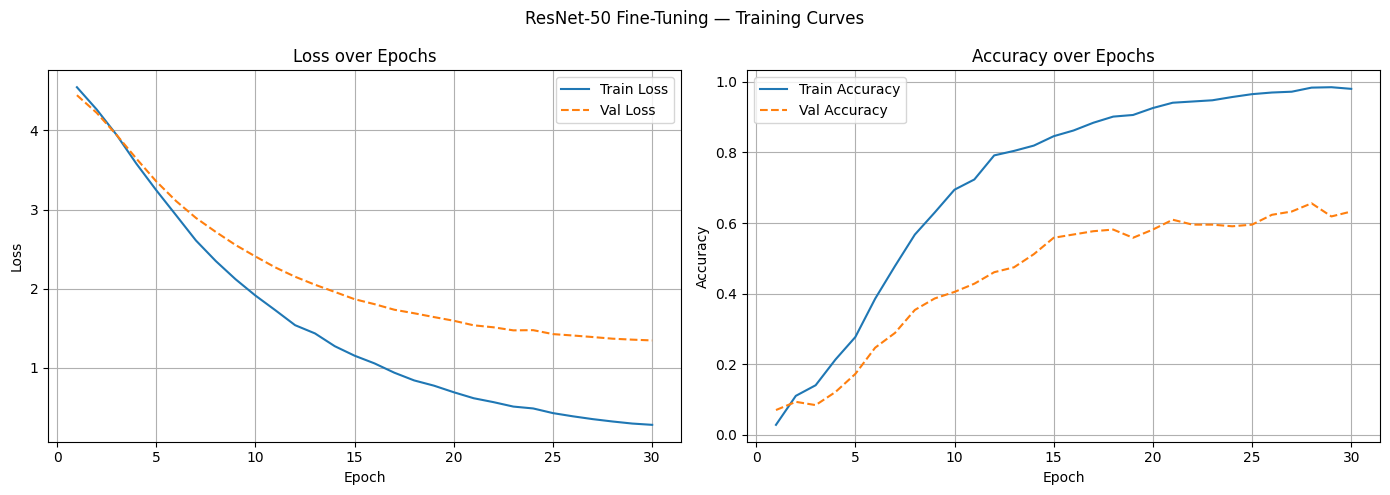

Best Val Accuracy: 0.6558


In [7]:
# ========================================
# Step 7 - Plot Curves
# ========================================

epochs = range(1, num_epochs + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
ax1.plot(epochs, train_losses, label='Train Loss')
ax1.plot(epochs, val_losses,   label='Val Loss', linestyle='--')
ax1.set_title('Loss over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# Accuracy curve
ax2.plot(epochs, train_accs, label='Train Accuracy')
ax2.plot(epochs, val_accs,   label='Val Accuracy', linestyle='--')
ax2.set_title('Accuracy over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.suptitle('ResNet-50 Fine-Tuning — Training Curves')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

print(f"Best Val Accuracy: {best_val_acc:.4f}")

In [8]:
# ========================================
# Step 8 - Test Evaluation
# ========================================
from PIL import Image

# Custom dataset for unlabeled test images — ImageFolder won't work since there are no label subfolders
class TestDataset(torch.utils.data.Dataset):
    def __init__(self, test_dir, transform):
        self.test_dir = test_dir
        self.transform = transform
        # Sort numerically: 0.jpg, 1.jpg, ..., 999.jpg (not alphabetically)
        self.image_files = sorted(os.listdir(test_dir), 
                                  key=lambda x: int(x.split('.')[0]))

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.test_dir, self.image_files[idx])
        image = Image.open(img_path).convert('RGB')  # convert to RGB in case grayscale
        if self.transform:
            image = self.transform(image)
        return image, self.image_files[idx]  # return image and its filename

# Test transforms — same as validation, no augmentation
test_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Load test dataset and dataloader
test_dataset = TestDataset(test_dir, transform=test_tf)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

# Load best checkpoint
model.load_state_dict(torch.load('best_model.pth', map_location=device))
model.eval()
print("Best checkpoint loaded.")

# Run inference on all test images
all_preds     = []
all_filenames = []

with torch.no_grad():
    for images, filenames in tqdm(test_loader):
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_filenames.extend(filenames)

# Generate submission.csv
submission = pd.DataFrame({'ID': all_filenames, 'Label': all_preds})
submission = submission.sort_values('ID', key=lambda x: x.str.split('.').str[0].astype(int))
submission.to_csv('submission.csv', index=False)

print(submission.head(10))
print(f"Submission saved — {len(submission)} predictions")

Best checkpoint loaded.


  0%|          | 0/33 [00:00<?, ?it/s]

      ID  Label
0  0.jpg     59
1  1.jpg     38
2  2.jpg     32
3  3.jpg     57
4  4.jpg     18
5  5.jpg     77
6  6.jpg     23
7  7.jpg     31
8  8.jpg     53
9  9.jpg     63
Submission saved — 1036 predictions
